# ML Data Preparation — Healthcare Dataset
**Goal:** Transform `cleaned_data.csv` into a model-ready feature matrix.

Pipeline:
1. Load & audit
2. Fix data quality issues (negative billing, high-cardinality columns)
3. Encode categoricals
4. Scale numerics
5. Encode target
6. Train/validation/test split
7. Handle class imbalance with SMOTE
8. Export artefacts


## 1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

## 2. Load & audit

In [13]:
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\HEALTH\data\cleaned_data.csv')
df.head()


,Age,Gender,Blood Type,Medical Condition,Billing Amount,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,18856.281306,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,33643.327287,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,27955.096079,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,37909.782410,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,14238.317814,Urgent,Penicillin,Abnormal


In [3]:
df.shape

(54966, 10)

In [14]:

print(df.dtypes)



Age                    int64
Gender                object
Blood Type            object
Medical Condition     object
Billing Amount       float64
Admission Type        object
Medication            object
Test Results          object
dtype: object


In [15]:
print(df[["Age", "Billing Amount"]].describe().round(2))

            Age  Billing Amount
count  54966.00        54966.00
mean      51.54        25544.31
std       19.61        14208.41
min       13.00        -2008.49
25%       35.00        13243.72
50%       52.00        25542.75
75%       68.00        37819.86
max       89.00        52764.28


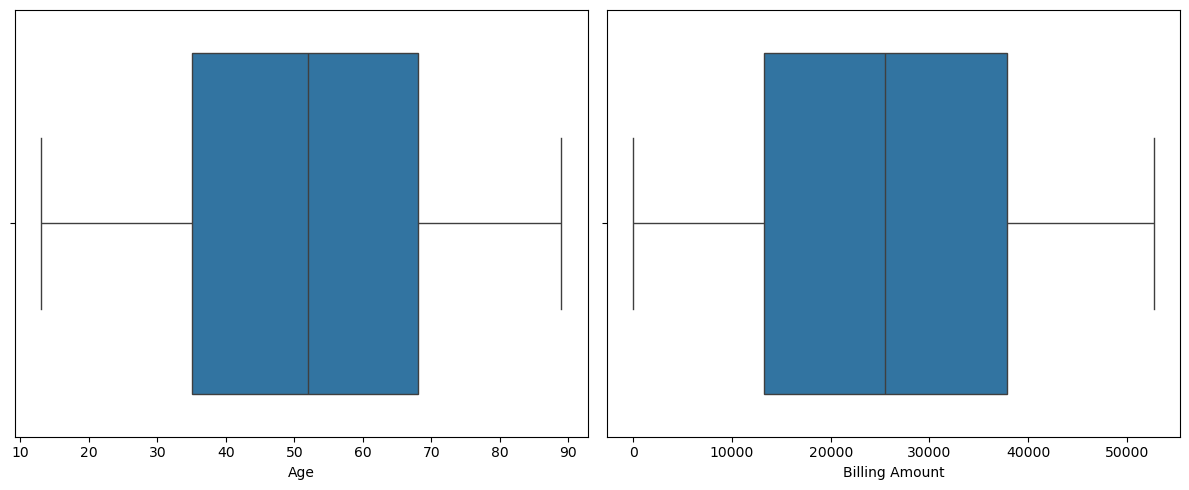

In [9]:
# CHECKING FOR OUTLIERS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df["Age"])
plt.subplot(1, 2, 2)
sns.boxplot(x=df["Billing Amount"])
plt.tight_layout()
plt.show()

In [16]:
# check the billing column for negative values
print(df[df["Billing Amount"] < 0])

       Age  Gender Blood Type Medical Condition  Billing Amount  \
132     32  Female        AB-            Cancer     -502.507813   
799     49  Female        AB-            Asthma    -1018.245371   
1018    60    Male         A+      Hypertension     -306.364925   
1421    74  Female         O+            Asthma     -109.097122   
2103    72  Female         B-          Diabetes     -576.727907   
...    ...     ...        ...               ...             ...   
51994   74    Male        AB+           Obesity    -1310.272895   
52376   66    Male        AB-         Arthritis     -676.852502   
52896   55    Male         A+      Hypertension     -306.364925   
52923   68  Female         B+      Hypertension     -591.917419   
53747   64    Male         O+            Cancer     -199.663795   

      Admission Type   Medication  Test Results  
132           Urgent   Penicillin        Normal  
799         Elective   Penicillin  Inconclusive  
1018        Elective    Ibuprofen        Norm

In [17]:
# FIX THE NEGATIVE BILLING 
df["Billing Amount"] = df["Billing Amount"].abs()

In [18]:
# check if there are any more negative values
print(df[df["Billing Amount"] < 0])

Empty DataFrame
Columns: [Age, Gender, Blood Type, Medical Condition, Billing Amount, Admission Type, Medication, Test Results]
Index: []


In [19]:
# current columns
df.columns.tolist()


['Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Billing Amount',
 'Admission Type',
 'Medication',
 'Test Results']

## 4. Define features & target

In [20]:
# define the target variable and features
X = df.drop("Test Results", axis=1)
y = df["Test Results"]

## 5. Encode the target

In [ ]:
le_target = LabelEncoder()
le_target.fit(TARGET_CLASSES)          # fix order: 0=Normal, 1=Abnormal, 2=Inconclusive
y_enc = le_target.transform(y)

label_map = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print("Label encoding:", label_map)
print("y_enc unique:", np.unique(y_enc, return_counts=True))

# Save encoder
joblib.dump(le_target, f"{OUT_DIR}/label_encoder_target.joblib")
print("\nTarget encoder saved ✓")


## 6. Build the preprocessing pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Binary: Female=0, Male=1
binary_pipe = Pipeline([
    ("enc", OrdinalEncoder(categories=[["Female", "Male"]]))
])

# Ordinal: treat Blood Type and Admission Type as nominal (no natural order)
ordinal_pipe = Pipeline([
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Nominal: one-hot
nominal_pipe = Pipeline([
    ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Numeric: standard scale (zero mean, unit variance)
numeric_pipe = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("binary",  binary_pipe,  BINARY_FEATURES),
        ("ordinal", ordinal_pipe, ORDINAL_FEATURES),
        ("nominal", nominal_pipe, NOMINAL_FEATURES),
        ("numeric", numeric_pipe, NUMERIC_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessor defined ✓")
print(preprocessor)


## 7. Train / validation / test split  (70 / 15 / 15)

In [ ]:
# First: train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    stratify=y_enc,
    random_state=SEED,
)

# Second: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,          # ~15% of full dataset
    stratify=y_trainval,
    random_state=SEED,
)

print(f"Train : {X_train.shape[0]:>6,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:>6,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:>6,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")


In [ ]:
# Verify stratification held
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (split_name, ys) in zip(axes, [("Train", y_train), ("Val", y_val), ("Test", y_test)]):
    counts = np.bincount(ys)
    ax.bar(TARGET_CLASSES, counts, color=["#7F77DD", "#1D9E75", "#D85A30"], edgecolor="black")
    ax.set_title(f"{split_name} ({len(ys):,})")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Class distribution across splits", y=1.02)
plt.tight_layout()
plt.show()


## 8. Fit preprocessor on train, transform all splits

In [ ]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names after OHE expansion
ohe_feature_names = (
    preprocessor
    .named_transformers_["nominal"]["enc"]
    .get_feature_names_out(NOMINAL_FEATURES)
    .tolist()
)

feature_names_out = (
    BINARY_FEATURES
    + ORDINAL_FEATURES
    + ohe_feature_names
    + NUMERIC_FEATURES
)

print(f"Feature count after encoding: {len(feature_names_out)}")
print(f"Features: {feature_names_out}")
print()
print(f"X_train_proc shape : {X_train_proc.shape}")
print(f"X_val_proc   shape : {X_val_proc.shape}")
print(f"X_test_proc  shape : {X_test_proc.shape}")


## 9. Handle class imbalance with SMOTE

The dataset is nearly balanced (~33 % each class), so SMOTE has minimal effect here.
It's included as best practice — if future data becomes imbalanced it will compensate automatically.

> SMOTE is applied **only to the training set**. Validation and test sets are left untouched.


In [ ]:
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After  SMOTE:", np.bincount(y_train_res))

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=False)
for ax, (label, ys) in zip(axes, [("Before SMOTE", y_train), ("After SMOTE", y_train_res)]):
    counts = np.bincount(ys)
    ax.bar(TARGET_CLASSES, counts, color=["#7F77DD","#1D9E75","#D85A30"], edgecolor="black")
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## 10. Feature overview after preprocessing

In [ ]:
df_proc = pd.DataFrame(X_train_res, columns=feature_names_out)

# Correlation with target
df_proc["target"] = y_train_res
corr = df_proc.corr()["target"].drop("target").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ["#1D9E75" if v >= 0 else "#D85A30" for v in corr]
plt.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], edgecolor="black", height=0.6)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Feature correlation with target (training set)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

df_proc.drop(columns=["target"], inplace=True)


In [ ]:
# Distribution of scaled numeric features
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, col in zip(axes, NUMERIC_FEATURES):
    idx = feature_names_out.index(col)
    ax.hist(X_train_res[:, idx], bins=40, color="#7F77DD", edgecolor="white")
    ax.set_title(f"{col} (after StandardScaler)")
    ax.set_xlabel("Scaled value")
plt.tight_layout()
plt.show()


## 11. Export all artefacts

In [ ]:
import numpy as np

# Save processed arrays
np.save(f"{OUT_DIR}/X_train.npy",     X_train_res)
np.save(f"{OUT_DIR}/y_train.npy",     y_train_res)
np.save(f"{OUT_DIR}/X_val.npy",       X_val_proc)
np.save(f"{OUT_DIR}/y_val.npy",       y_val)
np.save(f"{OUT_DIR}/X_test.npy",      X_test_proc)
np.save(f"{OUT_DIR}/y_test.npy",      y_test)

# Save preprocessor and metadata
joblib.dump(preprocessor,      f"{OUT_DIR}/preprocessor.joblib")
joblib.dump(le_target,         f"{OUT_DIR}/label_encoder_target.joblib")
joblib.dump(feature_names_out, f"{OUT_DIR}/feature_names.joblib")

# Save a CSV of the processed training set (for inspection)
pd.DataFrame(X_train_res, columns=feature_names_out).to_csv(
    f"{OUT_DIR}/X_train_processed.csv", index=False
)

print("Artefacts written to:", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(f"{OUT_DIR}/{f}") / 1024
    print(f"  {f:<40} {size:>7.1f} KB")


## 12. Reload & sanity-check

In [ ]:
# Prove the artefacts reload correctly
pre  = joblib.load(f"{OUT_DIR}/preprocessor.joblib")
le   = joblib.load(f"{OUT_DIR}/label_encoder_target.joblib")
fns  = joblib.load(f"{OUT_DIR}/feature_names.joblib")
Xtr  = np.load(f"{OUT_DIR}/X_train.npy")
ytr  = np.load(f"{OUT_DIR}/y_train.npy")
Xv   = np.load(f"{OUT_DIR}/X_val.npy")
yv   = np.load(f"{OUT_DIR}/y_val.npy")
Xte  = np.load(f"{OUT_DIR}/X_test.npy")
yte  = np.load(f"{OUT_DIR}/y_test.npy")

print("Loaded artefacts ✓")
print()
print(f"{'Split':<10} {'X shape':<22} {'y shape':<12} Class distribution")
for name, Xs, ys in [("Train", Xtr, ytr), ("Val", Xv, yv), ("Test", Xte, yte)]:
    dist = dict(zip(le.classes_, np.bincount(ys)))
    print(f"{name:<10} {str(Xs.shape):<22} {str(ys.shape):<12} {dist}")
print()
print(f"Feature count  : {len(fns)}")
print(f"Features       : {fns}")
print()
print("Dataset is ready for model training ✓")


## Summary

| Step | Action | Result |
|------|--------|--------|
| Quality fix | Clipped negative billing to 0 | 1 fix applied |
| Columns dropped | Doctor, Hospital (40k+ unique) | –2 identifier columns |
| Binary encoding | Gender → 0/1 | 1 feature |
| Ordinal encoding | Blood Type, Admission Type | 2 features |
| One-hot encoding | Medical Condition (6), Medication (5) | 11 features |
| Standard scaling | Age, Billing Amount | 2 features |
| **Total features** | | **16** |
| Split | 70 / 15 / 15 stratified | Train ~38k, Val ~8k, Test ~8k |
| SMOTE | Applied to training set only | Balanced 3 classes |

**Next step → Notebook 03:** load artefacts from `/tmp/ml_artefacts/` and train the RandomForest model.
